Running MCMC on 6 paired data points...


100%|██████████| 5000/5000 [00:03<00:00, 1334.97it/s]


H0: 64.59 +6.07 -5.93
eps: 0.033 +0.083 -0.073


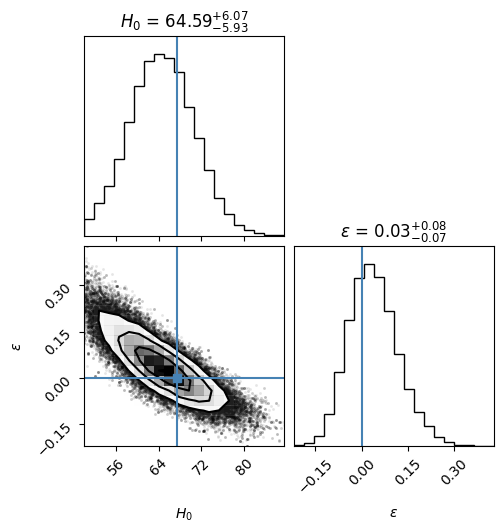

In [26]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt

# 1. 加载数据
z_raw, b_raw, t_raw = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
C_bao_full = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
m_gpr, C_m_gpr = np.load("output/mB_baomatch_mean_GPR_minimize.npy"), np.load("output/mB_baomatch_cov_GPR_minimize.npy")
h_gpr, C_h_gpr = np.load("output/cc_baomatch_mean_GPR.npy"), np.load("output/cc_baomatch_cov_GPR.npy")
z_all = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', usecols=0)

# 2. 筛选配对数据 (同时拥有 DM 和 DH 的红移点)
z_unq = np.unique(z_raw.astype(float))
pairs = [] 
for z in z_unq:
    idx = np.where(z_raw.astype(float) == z)[0]
    types = t_raw[idx]
    if 'DM_over_rs' in types and 'DH_over_rs' in types:
        k_m = idx[np.where(types == 'DM_over_rs')[0][0]]
        k_h = idx[np.where(types == 'DH_over_rs')[0][0]]
        k_gpr = np.where(np.unique(z_all) == z)[0][0] # 对应GPR结果的索引
        pairs.append([z, k_m, k_h, k_m])

pairs = np.array(pairs)
z_fit = pairs[:, 0]
idx_m, idx_h, idx_gpr = pairs[:, 1].astype(int), pairs[:, 2].astype(int), pairs[:, 3].astype(int)

# 3. 提取对应数据向量和协方差
dm, dh = b_raw[idx_m].astype(float), b_raw[idx_h].astype(float)
mb, h_cc = m_gpr[idx_gpr], h_gpr[idx_gpr]

C_m = C_m_gpr[np.ix_(idx_gpr, idx_gpr)]
C_h = C_h_gpr[np.ix_(idx_gpr, idx_gpr)]
# BAO协方差需提取 DM和DH 的块，保持相关性
idx_bao = np.concatenate([idx_m, idx_h])
C_bao_sub = C_bao_full[np.ix_(idx_bao, idx_bao)]

# 4. 构建观测向量 Y_obs 和 总协方差 C_tot
aB = 0.71723 # Riess et al. 2016
c_light = 299792.458

# Y_obs = [H_cc * 10^(0.2(mB + 5aB))] / [c * (1+z) * (DM/DH)]
num = h_cc * 10**(0.2 * (mb + 5 * aB))
den = c_light * (1 + z_fit) * (dm / dh)
y_obs = num / den

# 误差传播 (Jacobian)
N = len(z_fit)
J_m = np.diag(y_obs * 0.2 * np.log(10))          # dy/dmB
J_h = np.diag(y_obs / h_cc)                      # dy/dH
J_dm = np.diag(-y_obs / dm)                      # dy/dDM
J_dh = np.diag(y_obs / dh)                       # dy/dDH
J_bao = np.hstack([J_dm, J_dh])                  # 拼接用于乘以 C_bao_sub (2N x 2N)

C_tot = J_m @ C_m @ J_m.T + J_h @ C_h @ J_h.T + J_bao @ C_bao_sub @ J_bao.T

# 5. MCMC 采样
def log_prob(theta):
    h0, eps = theta
    if not (50 < h0 < 90 and -1.0 < eps < 1.0): return -np.inf
    # Model: Y = H0 * (1 + eps * z)
    model = h0 * (1 + eps * z_fit)
    diff = y_obs - model
    return -0.5 * diff @ np.linalg.solve(C_tot, diff)

ndim, nwalkers = 2, 32
p0 = [70.0, 0.0] + 1e-2 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)

print(f"Running MCMC on {N} paired data points...")
sampler.run_mcmc(p0, 5000, progress=True)

# 6. 结果
samples = sampler.get_chain(discard=1000, flat=True)
h0_mcmc = np.percentile(samples[:, 0], [16, 50, 84])
eps_mcmc = np.percentile(samples[:, 1], [16, 50, 84])

print(f"H0: {h0_mcmc[1]:.2f} +{h0_mcmc[2]-h0_mcmc[1]:.2f} -{h0_mcmc[1]-h0_mcmc[0]:.2f}")
print(f"eps: {eps_mcmc[1]:.3f} +{eps_mcmc[2]-eps_mcmc[1]:.3f} -{eps_mcmc[1]-eps_mcmc[0]:.3f}")

corner.corner(samples, labels=[r"$H_0$", r"$\epsilon$"], truths=[67.4, 0.0], show_titles=True)
plt.show()

In [24]:
pairs

array([[ 0.51 ,  1.   ,  2.   ,  1.   ],
       [ 0.706,  3.   ,  4.   ,  3.   ],
       [ 0.934,  5.   ,  6.   ,  5.   ],
       [ 1.321,  7.   ,  8.   ,  7.   ],
       [ 1.484,  9.   , 10.   ,  9.   ],
       [ 2.33 , 12.   , 11.   , 12.   ]])

In [25]:
h_cc

array([ 91.13285719, 103.42930401, 119.24214076, 146.68387566,
       157.26187106, 192.08141174])